# Differential Expression Analysis

## Objective

The PCA analysis suggested that ABC and GCB DLBCL samples exhibit distinct transcriptional profiles. To identify the specific genes responsible for these differences, differential expression analysis was performed.

The goals of this analysis were to:

1. Identify genes that are significantly differentially expressed between ABC and GCB DLBCL.
2. Quantify the magnitude and direction of expression changes.
3. Control for multiple hypothesis testing.
4. Generate a ranked gene list for downstream pathway enrichment analysis.

Genes with positive log2 fold changes are more highly expressed in ABC DLBCL, while genes with negative log2 fold changes are more highly expressed in GCB DLBCL.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

In [2]:
expr_df = pd.read_csv("../data/processed/GSE10846_expr_matrx.csv",  index_col=0 )
meta_df = pd.read_csv("../data/processed/GSE10846_metadata.csv",  index_col=0 )

## Experimental Design

The comparison was performed between two molecular subtypes:

* GCB DLBCL (reference group)
* ABC DLBCL

Subtype labels were encoded as:

* GCB = 0
* ABC = 1

For each gene, a linear model was fitted to estimate the relationship between subtype and expression level.

The resulting coefficient represents the log2 fold change between ABC and GCB tumors.


In [3]:
meta_df["Subtype_Code"] = meta_df["Subtype"].map({"GCB": 0, "ABC": 1})

In [4]:
X = meta_df["Subtype_Code"]
X = sm.add_constant(X)

## Statistical Testing

A separate linear regression model was fitted for each gene:

Expression ~ Subtype

For every gene, two statistics were extracted:

* Log2 Fold Change (log2FC)
* P-value

Because thousands of genes were tested simultaneously, false discovery rate (FDR) correction was applied using the Benjamini-Hochberg procedure.


In [5]:
results = []
print("Running differential expression analysis...")
for gene in expr_df.index:
    y = expr_df.loc[gene]
    
    model = sm.OLS(y, X).fit()
    
    log2FC = model.params["Subtype_Code"]
    p_val = model.pvalues["Subtype_Code"]
    
    results.append({"gene": gene, "log2FC": log2FC, "pvalue": p_val})

Running differential expression analysis...


In [6]:
dea_results = pd.DataFrame(results).set_index("gene")

In [7]:
rejected, pvals_corrected, _, _ = multipletests(
    dea_results["pvalue"], 
    alpha=0.05, 
    method="fdr_bh"
)

dea_results["padj"] = pvals_corrected

In [8]:
print(f"Analysis complete! Found {sum(rejected)} significantly dysregulated genes.")

Analysis complete! Found 4808 significantly dysregulated genes.


## Differential Expression Results

A total of **4,901 genes** were identified as significantly differentially expressed after Benjamini-Hochberg false discovery rate correction (FDR < 0.05).

This large number of dysregulated genes suggests substantial transcriptional differences between ABC and GCB DLBCL, consistent with their distinct biological origins and clinical behavior.

The strongest signals likely represent subtype-defining genes and pathways that contribute to lymphoma pathogenesis.

In [9]:
dea_results.sort_values(by="padj").head(10)

,log2FC,pvalue,padj
gene,,,
ASB13,-1.842786,4.791217e-31,1.096230e-26
SERPINA9,-4.185809,1.045184e-30,1.195690e-26
BATF,1.710624,6.756032e-30,5.152600e-26
SYTL4,-2.246543,2.980860e-29,1.705052e-25
MME,-3.298431,2.118212e-28,9.692936e-25
SNX29P1,-3.982671,5.838808e-28,2.001607e-24
MYBL1,-2.150034,6.123797e-28,2.001607e-24
RP11-138I18.2,-2.218478,6.960772e-27,1.990781e-23
BCL6,-1.336438,2.013525e-26,5.118829e-23


## Top Differentially Expressed Genes

The table below displays the most statistically significant genes identified in the analysis.

Negative log2 fold changes indicate higher expression in GCB DLBCL, whereas positive log2 fold changes indicate higher expression in ABC DLBCL.

### Biological Interpretation of Top Hits

Several highly significant genes correspond to known biological differences between ABC and GCB DLBCL.

Examples include:

* **BCL6**: A master regulator of germinal center B-cell development and a well-established marker of the GCB subtype.
* **MME (CD10)**: A canonical germinal center marker frequently expressed in GCB DLBCL.
* **SERPINA9**: Commonly associated with germinal center B cells and lymphoid biology.
* **BATF**: A transcription factor involved in activated B-cell programs and immune signaling.

The presence of established subtype markers among the most significant genes provides biological validation for the differential expression analysis and supports the quality of the dataset.


In [10]:
upregulated = (
    (dea_results["padj"] < 0.05)
    & (dea_results["log2FC"] > 1)
).sum()

downregulated = (
    (dea_results["padj"] < 0.05)
    & (dea_results["log2FC"] < -1)
).sum()

print(upregulated, downregulated)

143 279


### Summary of Differential Expression

A total of 4,901 genes were significantly differentially expressed after FDR correction (adjusted p-value < 0.05).

To focus on genes with both statistical significance and biologically meaningful effect sizes, an additional fold-change threshold of |log2FC| > 1 was applied.

| Category | Number of Genes |
|-----------|-----------|
| Significant (FDR < 0.05) | 4,901 |
| Upregulated in ABC (FDR < 0.05, log2FC > 1) | 146 |
| Upregulated in GCB (FDR < 0.05, log2FC < -1) | 282 |
| Total large-effect DE genes | 428 |

## Volcano Plot

A volcano plot was generated to visualize both the magnitude and statistical significance of differential expression results.

Genes were classified as:

- Upregulated in ABC:
  - FDR < 0.05
  - log2FC > 1

- Downregulated in ABC:
  - FDR < 0.05
  - log2FC < -1

- Not Significant:
  - All remaining genes

In [11]:
p_thresh = 0.05
fc_thresh = 1.0

dea_results['-log10_padj'] = -np.log10(dea_results['padj'] + 1e-300)

conditions = [
    (dea_results['padj'] < p_thresh) & (dea_results['log2FC'] > fc_thresh),
    (dea_results['padj'] < p_thresh) & (dea_results['log2FC'] < -fc_thresh)
]
choices = ['Upregulated in ABC', 'Downregulated in ABC']
dea_results['Significance'] = np.select(conditions, choices, default='Not Significant')

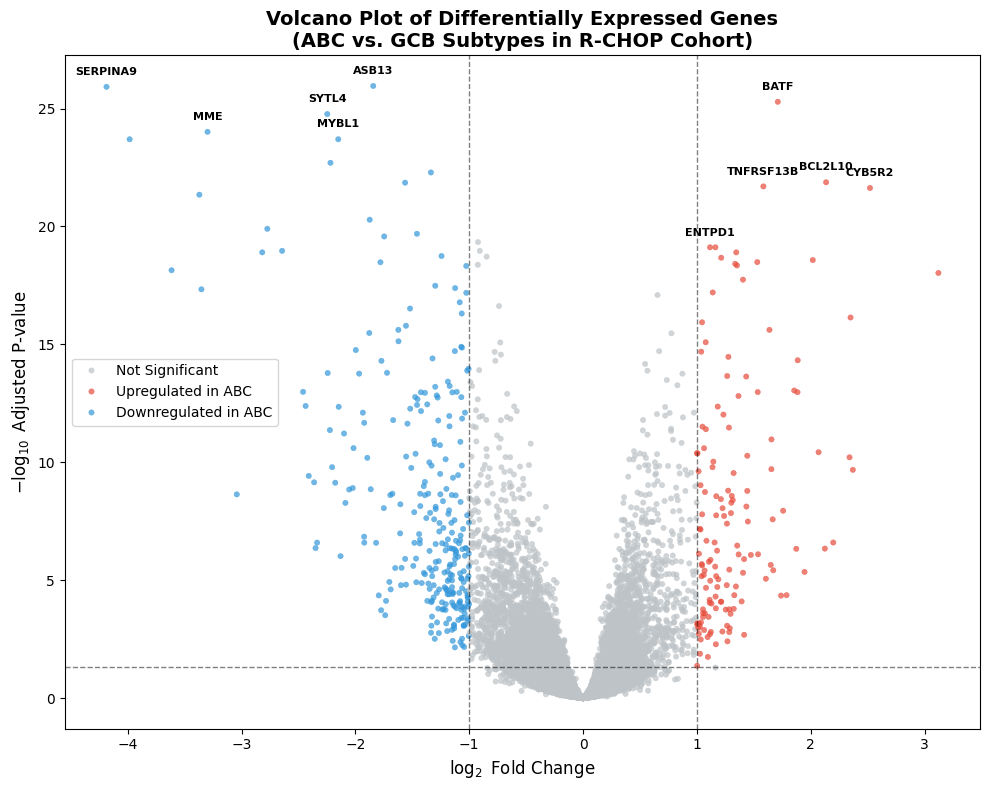

In [12]:
plt.figure(figsize=(10, 8))

color_dict = {
    'Upregulated in ABC': '#e74c3c',    
    'Downregulated in ABC': '#3498db',  
    'Not Significant': '#bdc3c7'       
}


sns.scatterplot(
    data=dea_results,
    x='log2FC',
    y='-log10_padj',
    hue='Significance',
    palette=color_dict,
    alpha=0.7,
    edgecolor=None,
    s=15
)


plt.axhline(-np.log10(p_thresh), color='black', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(fc_thresh, color='black', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(-fc_thresh, color='black', linestyle='--', alpha=0.5, linewidth=1)

top_abc = dea_results[dea_results['Significance'] == 'Upregulated in ABC'].nsmallest(5, 'padj')
top_gcb = dea_results[dea_results['Significance'] == 'Downregulated in ABC'].nsmallest(5, 'padj')

for gene, row in pd.concat([top_abc, top_gcb]).iterrows():
    plt.text(
        row['log2FC'], 
        row['-log10_padj'] + 0.5, 
        gene, 
        fontsize=8, 
        weight='bold',
        ha='center'
    )


plt.title('Volcano Plot of Differentially Expressed Genes\n(ABC vs. GCB Subtypes in R-CHOP Cohort)', fontsize=14, weight='bold')
plt.xlabel('$\log_2$ Fold Change', fontsize=12)
plt.ylabel('$-\log_{10}$ Adjusted P-value', fontsize=12)
plt.legend(loc='best', frameon=True)
plt.tight_layout()

plt.savefig("../results/figures/volcano_plot.png", dpi=300)
plt.show()

### Interpretation

The volcano plot reveals widespread transcriptional differences between ABC and GCB DLBCL.

Key observations include:

* Thousands of genes pass statistical significance thresholds.
* Numerous genes display large expression differences exceeding two-fold changes.
* Both upregulated and downregulated genes are observed, indicating extensive subtype-specific transcriptional reprogramming.
* Several known subtype markers occupy the extreme regions of the plot, further supporting the biological validity of the analysis.

The broad distribution of significant genes suggests that ABC and GCB DLBCL are characterized by fundamentally distinct molecular programs rather than isolated changes in a small number of genes.

In [13]:
dea_ranked = dea_results.sort_values(
    by=["Significance", "padj"],
    ascending=[False, True]
)

In [14]:
dea_ranked.to_csv("../results/tables/GSE10846_dea_results.csv")

# Conclusions

Differential expression analysis identified extensive transcriptional differences between ABC and GCB DLBCL.

Major findings include:

1. 4,901 genes were significantly dysregulated between subtypes.
2. Numerous known DLBCL subtype markers emerged among the strongest signals.
3. Both ABC-specific and GCB-specific transcriptional programs were evident.
4. The results support the biological distinction between the two molecular subtypes.

The ranked gene list generated in this notebook will be used in the next stage of the analysis to identify biological pathways and molecular processes enriched in each subtype.